## Imports


In [1]:
import sys, torch, scprep
sys.path.append('../')
import warnings; warnings.filterwarnings('ignore')
from torch import optim
import torchvision; from torchvision import datasets, transforms
import numpy as np
import matplotlib; import matplotlib.pyplot as plt
import graphtools as gt
import networkx as nx
import scipy
from torch import nn
from sklearn.model_selection import train_test_split
from abc import abstractmethod
import scanpy as sc
from typing import List, Callable, Union, Any, TypeVar, Tuple
from torch.utils.data import DataLoader, TensorDataset

## Loading Datasets  

### MNIST Dataset

In [2]:
# --- Load MNIST ---
mnist = datasets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
X = mnist.data.numpy().reshape(60000, -1)   # raw pixels (0–255)
y = mnist.targets.numpy()

# --- Balanced sample: 1000 per digit ---
idx = np.hstack([np.random.choice(np.where(y == d)[0], 1000, replace=False) for d in range(10)])
X_subset = X[idx]    # (10000, 784)

# --- Linear version (features × samples), range [0,1] ---
MNIST_v1 = torch.from_numpy((X_subset / 255).T).double()   

# --- Deep-learning version (samples × features), range [-1,1] ---
MNIST_v2 = torch.from_numpy(((X_subset / 255) * 2 - 1)).double()

# --- Diagnostics ---
print("MNIST_v1:", MNIST_v1.shape,
      "range:", (MNIST_v1.min().item(), MNIST_v1.max().item()))

print("MNIST_v2:    ", MNIST_v2.shape,
      "range:", (MNIST_v2.min().item(), MNIST_v2.max().item()))


MNIST_v1: torch.Size([784, 10000]) range: (0.0, 1.0)
MNIST_v2:     torch.Size([10000, 784]) range: (-1.0, 1.0)


### Sequence RNA dataset

In [4]:
"""Load from link"""
#Download data also available at https://www.kaggle.com/datasets/alexandervc/scrnaseq-scatacseq-challenge-at-neurips-2021
import os
import urllib.request

# Define the local filename
destination = "./data/GSE194122_openproblems_neurips2021_multiome_BMMC_processed.h5ad"

# This is the direct link to the processed challenge dataset on Figshare
# (Maintained by the Open Problems team)
url = "https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSE194122&format=file&file=GSE194122%5Fopenproblems%5Fneurips2021%5Fmultiome%5FBMMC%5Fprocessed%2Eh5ad%2Egz" 

print(f"Downloading dataset from original source (Figshare)...")

if not os.path.exists(destination):
    urllib.request.urlretrieve(url, destination)
    print("Download complete!")
else:
    print("File already exists.")

fn = './data/GSE194122_openproblems_neurips2021_multiome_BMMC_processed.h5ad'
adata = sc.read(fn)    

KeyboardInterrupt: 

In [2]:
"""or load from local .zip"""
import zipfile
import tempfile

with zipfile.ZipFile("scRNA-seq.zip") as z:
    # find the .h5ad file
    h5ad_name = [f for f in z.namelist() if f.endswith(".h5ad")][0]

    # Extract to a temporary file
    with tempfile.NamedTemporaryFile(suffix=".h5ad", delete=False) as tmp:
        tmp.write(z.read(h5ad_name))
        tmp.flush()
        temp_path = tmp.name

# Load h5ad using disk access, not RAM
adata = sc.read_h5ad(temp_path, backed="r")



In [4]:
#there is 50 principal commponets in total, so no need to explicetly say it
adata.obsm['GEX_X_pca'].shape

(69249, 50)

In [30]:
# For now choose the subset, but we need to take whole dataset (its not that big)
adata_subset = sc.pp.subsample(adata, n_obs=10000, copy=True, random_state=42)

#labels
y = adata_subset.obs["cell_type"].to_numpy()

In [31]:
#@FABIAN, you might need to do smth about range here
sqRNA_v1 = torch.tensor(adata_subset.obsm['GEX_X_pca'], dtype=torch.float64).T
# --- Diagnostics ---
print("sqRNA_v1 shape:", sqRNA_v1.shape,
      "range:", (sqRNA_v1.min().item(), sqRNA_v1.max().item()))

sqRNA_v1 shape: torch.Size([50, 10000]) range: (-10.944077491760254, 26.201128005981445)


In [32]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(-1, 1))

sqRNA_v2 = scaler.fit_transform(adata_subset.obsm['GEX_X_pca'])           
sqRNA_v2 = torch.from_numpy(sqRNA_v2).float()   # convert to torch

print("sqRNA_v2 shape:", sqRNA_v2.shape,
      "range:", (sqRNA_v2.min().item(), sqRNA_v2.max().item()))



sqRNA_v2 shape: torch.Size([10000, 50]) range: (-1.0, 1.000000238418579)


In [23]:
print("sqRNA_v2:", sqRNA_v2.shape,
      "range:", (sqRNA_v2.min().item(), sqRNA_v2.max().item()))

sqRNA_v2: torch.Size([1000, 50]) range: (-1.0, 1.0000001192092896)


## Helper fuctions
general Functions:  
NMI  
Confidence  
...

In [8]:
from scipy.spatial.distance import pdist, squareform
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'




def ArchetypeConsistency(XC1, XC2, mSST):
    """
    Calculates the consistency between two sets of archetypes (XC1 and XC2).
    """
    # 1. Calculate Squared Euclidean Distance between all archetypes
    D = squareform(pdist(np.hstack((XC1, XC2)).T, 'euclidean'))**2
    D = D[:XC1.shape[1], XC1.shape[1]:]

    # 2. Greedy Matching to pair archetypes
    i = []
    j = []
    v = []
    K = XC1.shape[1]
    
    for k in range(K):
        # Find minimum distance in the matrix
        min_index = np.unravel_index(np.argmin(D, axis=None), D.shape)
        i.append(min_index[0])
        j.append(min_index[1])
        v.append(D[i[-1], j[-1]]) # Record the error (distance)
        
        # 'Remove' these from future consideration
        D[i[-1], :] = np.inf
        D[:, j[-1]] = np.inf

    # 3. Calculate Consistency Score (R^2-like metric)
    consistency = 1 - np.mean(v) / mSST

    # 4. Calculate Inter-Set Similarity Index (ISI)
    # Correlation between matched archetypes
    D2 = np.abs(np.corrcoef(np.hstack((XC1, XC2)).T))
    D2 = D2[:K, K:]
    ISI = 1 / (2 * K * (K - 1)) * (np.sum(D2 / np.max(D2, axis=1, keepdims=True) + D2 / np.max(D2, axis=0, keepdims=True)) - 2 * K)
    
    return consistency, ISI

def preprocess(X):
    """
    Mean-centers the data and computes the total variance (mSST).
    """
    meanX = np.mean(X, axis=0)
    X_centered = X - meanX
    # Mean Sum of Squares Total (Total Variance)
    mSST = np.sum(np.mean(X_centered**2, axis=0))
    return X_centered, mSST

def calcMI(z1,z2):
    eps = 10e-16
    P = z1@z2.T
    PXY = P/P.sum()
    PXPY = np.outer(np.expand_dims(PXY.sum(1), axis=0),np.expand_dims(PXY.sum(0), axis=1))
    ind = np.nonzero(PXY>0)
    MI = np.sum(PXY*np.log(eps+PXY/(eps+PXPY)))
    return MI
    
def calcNMI(z1,z2):
    NMI=(2*calcMI(z1,z2))/(calcMI(z1,z1)+calcMI(z2,z2))
    #NMI = NMI.reshape((z1.shape[0], z1.shape[0]))
    
    return NMI

def plot_loss_arc(L,n_arc_list,i,color,model, dataset, savedir = None):


    fig, ax = plt.subplots(figsize=(15, 5),layout='constrained')

    ax.errorbar(n_arc_list,np.mean(L,axis=1),yerr=np.std(L,axis=1),c=color,label=f'{model} - {dataset}')

    ##
    # ax.set_xticks(n_arc_list,fontsize=25)
    ax.set_xticks(n_arc_list)       # Set the tick positions
    ax.tick_params(axis='x') # Set the font size separately
    ##

    ax.set_xlabel('Number of Archetypes',fontsize=30)
    ax.set_ylabel('Loss',fontsize=30)

    plt.legend(fontsize=30)

    plt.yticks(fontsize=25)
    plt.xticks(fontsize=25)    
    #plt.title(f'{model} - {dataset}',fontsize=30)

    if savedir is not None:
        plt.savefig(savedir+f"/loss_layer_"+str(i)+".png")
        plt.close()
    else:
        plt.show()

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_nmi_stability(NMI,n_arc_list,model,dataset, colors, savedir = None):
    
    
    df = pd.DataFrame(NMI.T)
    df['Method'] = f'Model {model}'


    df = df.melt(id_vars='Method', var_name='Archetypes', value_name='NMI')
    fig, ax = plt.subplots(1,1,figsize = (15,5), layout='constrained')

    ax = sns.boxplot(x='Archetypes', y="NMI", hue="Method", showmeans=True, data=df,palette=colors,meanprops={"marker": "s", "markerfacecolor": "white", "markeredgecolor": "black"})
    ax.xaxis.grid(True, which='major')
    [ax.axvline(x+.5,color='k') for x in ax.get_xticks()]
    plt.xticks(np.arange(len(n_arc_list)),n_arc_list,fontsize=25)
    plt.yticks(fontsize=25)    
    ax.set_xlabel('Number of archetypes', fontsize=30)
    ax.set_ylabel('NMI', fontsize=30)

    ax.set_ylim([0,1.05])
    plt.legend(fontsize=30,loc = 'lower right')
    plt.title(f'{model} - {dataset}',fontsize=30)
    
    if savedir is not None:
        plt.savefig(savedir+f"/NMI_model_"+str(model)+"dataset_"+str(dataset)+".png")
        plt.close()
    else:
        plt.show()

## Linear AA Implementation

In [3]:
from LinearAA.AALS import AALS
import torch
import numpy as np 
import matplotlib.pyplot as plt
from tqdm import tqdm
import itertools
colors = ["#EF476F",  "#06D6A0", "#FFD166", "#073B4C", "#118AB2", "#FF6B6B", "#C8A2C8"]

In [6]:
# Show small test
# running linear AA on mini subset, 4 times for each archetype, we run it multiple times for each archetype to see stability (NMI)
test_Linear_X = MNIST_v1[:, :50]
n_runs = 4
n_arc_list = [f for f in range(2,15)]
Losses = np.zeros((len(n_arc_list),n_runs))
Ss = np.zeros((len(n_arc_list),n_runs),dtype=object)

for n in tqdm(n_arc_list):
    for i in range(n_runs):

        C,S,L,EV = AALS(test_Linear_X, n)
        Losses[n_arc_list.index(n),i] = L[-1]
        Ss[n_arc_list.index(n),i] = S
        

100%|███████████████████████████████████████████████████████████████████████████████████| 13/13 [00:12<00:00,  1.07it/s]


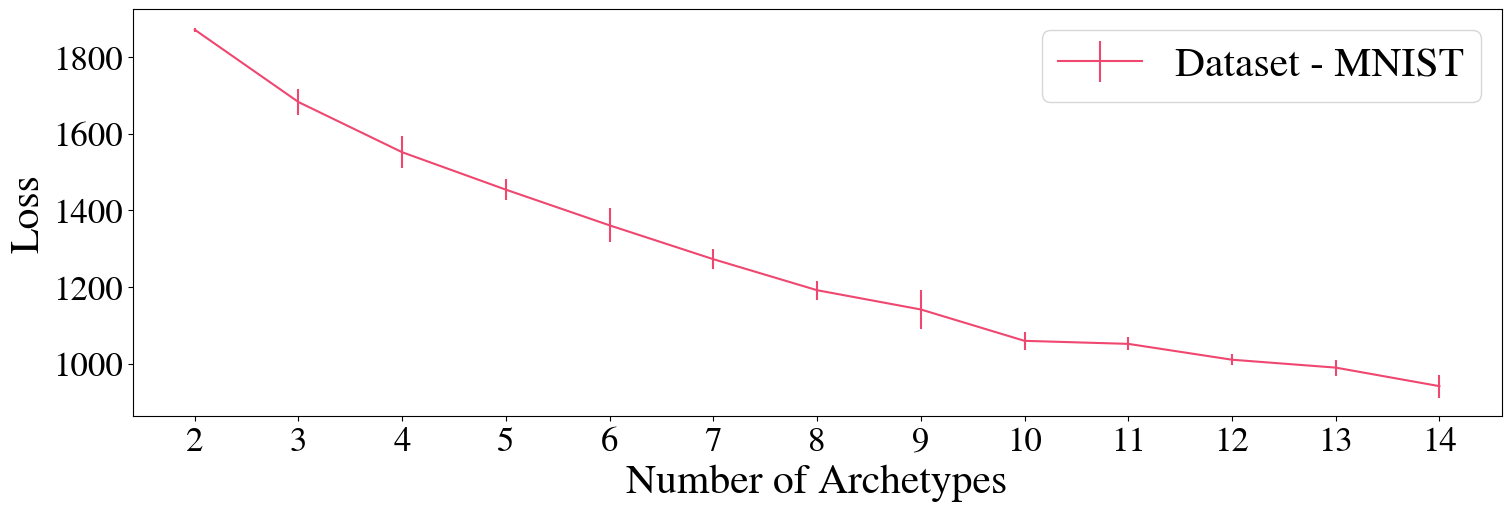

In [9]:
plot_loss_arc(Losses,n_arc_list,i,colors[0],'Dataset', 'MNIST', savedir = None)

100%|██████████| 13/13 [00:00<00:00, 552.62it/s]
C:\Users\fabia\AppData\Local\Temp\ipykernel_12252\2142883590.py:113: UserWarning: The palette list has more values (7) than needed (1), which may not be intended.
  ax = sns.boxplot(x='Archetypes', y="NMI", hue="Method", showmeans=True, data=df,palette=colors,meanprops={"marker": "s", "markerfacecolor": "white", "markeredgecolor": "black"})


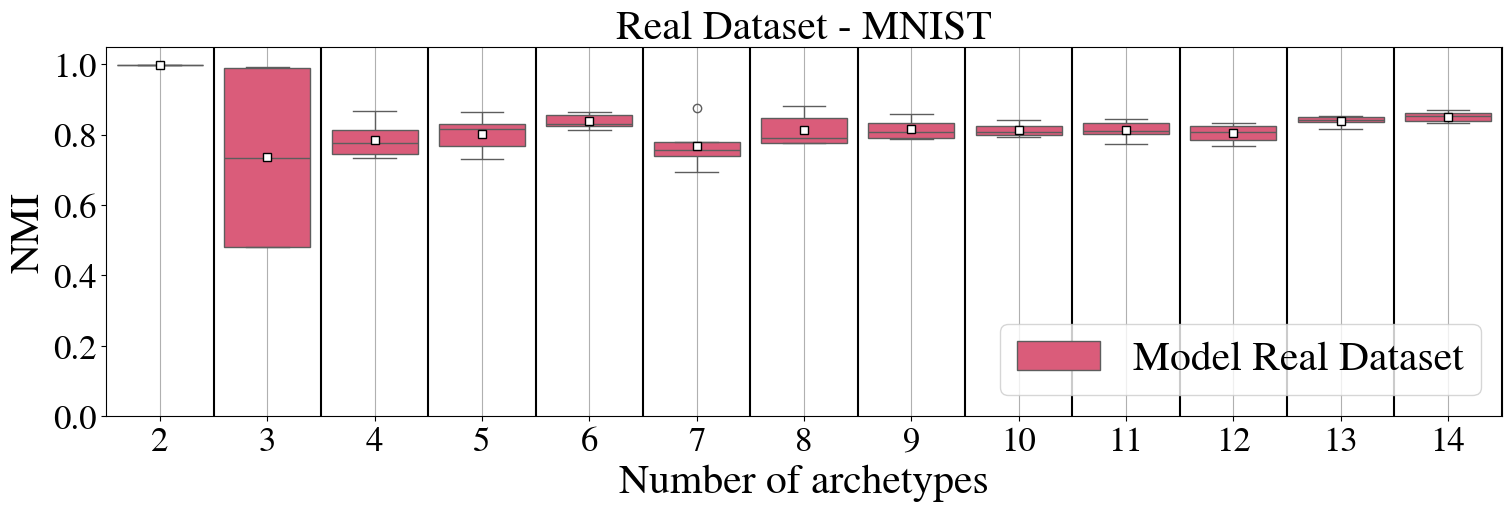

In [8]:
test = itertools.combinations(range(n_runs), 2)
t = list(test)
calcIDX = np.array(t)

NMI = np.zeros((len(n_arc_list),len(calcIDX)))

for n in tqdm(n_arc_list):
    for j in range(len(calcIDX)):

        S1 = np.asarray(Ss[n_arc_list.index(n),calcIDX[j,0]])
        S2 = np.asarray(Ss[n_arc_list.index(n),calcIDX[j,1]])


        NMI[n_arc_list.index(n),j] = calcNMI(S1,S2)

plot_nmi_stability(NMI,n_arc_list, 'Real Dataset','MNIST',colors)

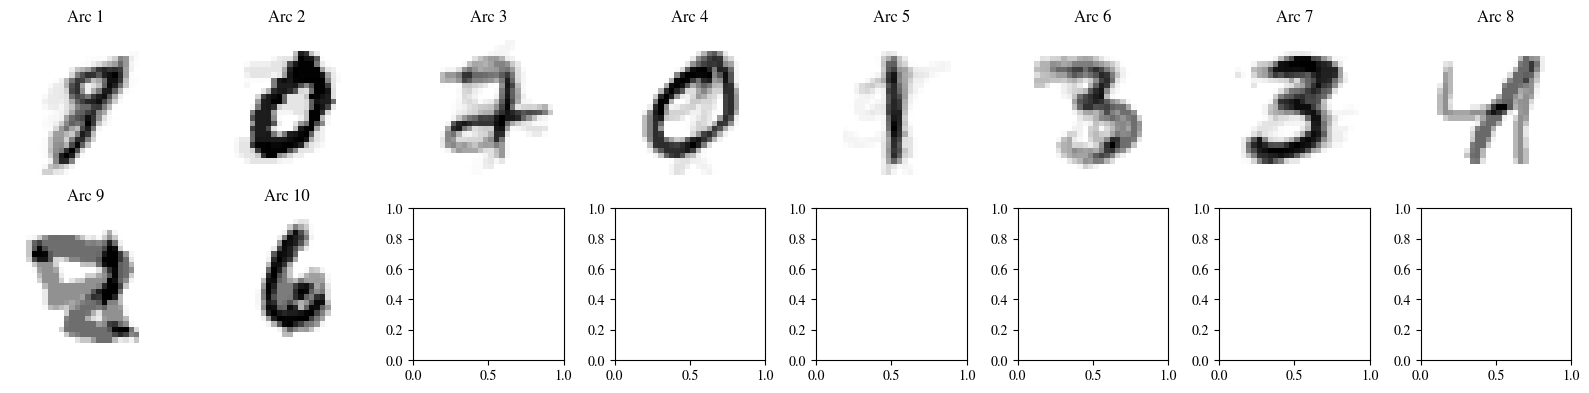

In [9]:
n_archetypes = 10
C_final, S_final, L_final, EV_final = AALS(test_Linear_X, n_archetypes)

# 1. Calculate the actual Archetypes (Z = X * C)
# Ensure both are the same type (likely Torch tensors based on your output)
if isinstance(C_final, np.ndarray):
    C_final = torch.from_numpy(C_final)
if isinstance(test_Linear_X, np.ndarray):
    test_Linear_X = torch.from_numpy(test_Linear_X)

# Matrix Multiplication: (784x100) @ (100x16) -> (784x16)
archetypes_matrix = torch.matmul(test_Linear_X, C_final) 
# 2. Visualize
n_archetypes = archetypes_matrix.shape[1] # Should be 16
rows = int(n_archetypes // 8) + 1  # Adjust grid (2x8 = 16)
cols = 8 # Adjust grid (2x8 = 16)

fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 2))
axes = axes.flatten()

for i in range(n_archetypes):
    # Get the i-th archetype (all 784 pixels)
    arc_vector = archetypes_matrix[:, i]
    
    # Reshape to 28x28 image
    arc_img = arc_vector.reshape(28, 28).detach().numpy() # detach if it requires grad
    
    axes[i].imshow(arc_img, cmap='gray_r')
    axes[i].set_title(f"Arc {i+1}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## AAnet implementation

In [24]:
def train_epoch(model, data_loader, optimizer, epoch, gamma_reconstruction=1.0, gamma_archetypal=1.0, gamma_extrema=1.0):
    loss = 0
    reconstruction_loss = 0
    archetypal_loss = 0
    extrema_loss = 0

    for idx, data in enumerate(data_loader):
        
        # if input is list, then data_loader contains features and target
        # assume first input is features based on data_loader structure
        if isinstance(data, list):
            batch_features = data[0]
        else:
            batch_features = data
        
        # if there are extrema, add diffusion extrema to beginning of each batch
        # first n_archetypes samples are used in extrema loss
        if model.diffusion_extrema is not None:
            batch_features = torch.cat((model.diffusion_extrema.view(-1, model.input_shape),
                                    batch_features.view(-1, model.input_shape)), 0)
            
        # reshape mini-batch data to [N, input_shape] matrix
        batch_features = batch_features.view(-1, model.input_shape)
        
        # load it to the active device
        batch_features = batch_features.to(model.device)

        # reset the gradients back to zero
        # PyTorch accumulates gradients on subsequent backward passes
        optimizer.zero_grad()

        # compute reconstructions
        output, _in, archetypal_embedding = model(batch_features.float())

        # compute training reconstruction loss
        curr_reconstruction_loss = torch.mean((output - batch_features)**2)
        reconstruction_loss += curr_reconstruction_loss

        # compute training archetypal loss
        curr_archetypal_loss = model.calc_archetypal_loss(archetypal_embedding)
        archetypal_loss += curr_archetypal_loss
        
        # compute training diffusion extrema loss
        if model.diffusion_extrema is not None:
            curr_extrema_loss = model.calc_diffusion_extrema_loss(archetypal_embedding)
            extrema_loss += curr_extrema_loss
        else:
            curr_extrema_loss = 0
            extrema_loss = 0
            
        # extrema penalization decreases over batches and epochs
        # this enables AAnet to learn the correct archetypes if the diffusion extrema are not close
        train_loss = gamma_reconstruction * curr_reconstruction_loss + \
                     gamma_archetypal * curr_archetypal_loss + \
                     gamma_extrema /(epoch * len(data_loader) + (idx+1)) * curr_extrema_loss

        # compute accumulated gradients
        train_loss.backward()

        # perform parameter update based on current gradients
        optimizer.step()

        # add the mini-batch training loss to epoch loss
        loss += train_loss.item()

    # compute the epoch training loss
    loss = loss / len(data_loader)
    reconstruction_loss = reconstruction_loss / len(data_loader)
    archetypal_loss = archetypal_loss / len(data_loader)
    return loss, reconstruction_loss, archetypal_loss

In [25]:
class AAnet_vanilla(nn.Module):
    def __init__(
        self,
        input_shape,
        n_archetypes=4,
        noise=0,
        layer_widths=[128, 128],
        activation_out="tanh",
        simplex_scale=1,
        device=None,
        diffusion_extrema=None,
        **kwargs
    ):
        super().__init__()

        self.input_shape = input_shape
        self.n_archetypes = n_archetypes
        self.noise = noise
        self.layer_widths = layer_widths
        self.activation_out = activation_out
        self.simplex_scale = simplex_scale
        self.diffusion_extrema = diffusion_extrema
        
        if device is None:
            self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        else:
            self.device = device

        # ---------------------------
        # Encoder network
        # ---------------------------
        self.encoder_layers = nn.ModuleList()
        for i, width in enumerate(layer_widths):
            in_features = input_shape if i == 0 else layer_widths[i - 1]
            self.encoder_layers.append(nn.Linear(in_features, width))

        # Last encoder layer → latent dims = n_archetypes - 1
        self.encoder_layers.append(nn.Linear(layer_widths[-1], n_archetypes - 1))

        # ---------------------------
        # Decoder network
        # ---------------------------
        self.decoder_layers = nn.ModuleList()
        decoder_widths = layer_widths[::-1]

        for i, width in enumerate(decoder_widths):
            in_features = n_archetypes - 1 if i == 0 else decoder_widths[i - 1]
            self.decoder_layers.append(nn.Linear(in_features, width))

        # Last decoder layer → reconstruct input
        self.decoder_layers.append(
            nn.Linear(decoder_widths[-1], input_shape)
        )

        # Precompute archetypal simplex
        self.archetypal_simplex = self.get_n_simplex(n_archetypes, simplex_scale)

        self.to(self.device)

    # ============================================================
    # Utility functions (migrated from BaseAAnet)
    # ============================================================

    def get_n_simplex(self, n=2, scale=1):
        """Returns an n-simplex centered at the origin."""
        nth = (1/(n-1)*(1-np.sqrt(n))) * np.ones(n-1)
        D = np.vstack([np.eye(n-1), nth]) * scale
        return torch.tensor(D - np.mean(D, axis=0), dtype=torch.float, device=self.device)

    def euclidean_to_barycentric(self, X):
        """Convert Euclidean → barycentric coordinates."""
        simplex = self.archetypal_simplex

        T = torch.zeros((X.shape[1], X.shape[1])).to(self.device)
        for i in range(X.shape[1]):
            for j in range(X.shape[1]):
                T[i, j] = simplex[i, j] - simplex[-1, j]

        T_inv = torch.inverse(T).float().to(self.device)

        X_bary = torch.einsum("ij,bj->bi", T_inv, X - simplex[-1])
        X_bary = torch.cat(
            [X_bary, (1 - torch.sum(X_bary, dim=1, keepdim=True))],
            dim=1
        )
        return X_bary

    def dist_to_simplex(self, X_bary):
        """Distance penalty for barycentric coords outside simplex."""
        return torch.sum(torch.clamp(-X_bary, min=0), dim=1)

    def calc_archetypal_loss(self, archetypal_embedding):
        """Archetypal loss = MSE of distance to simplex."""
        X_bary = self.euclidean_to_barycentric(archetypal_embedding)
        return torch.mean(self.dist_to_simplex(X_bary) ** 2)

    def calc_diffusion_extrema_loss(self, archetypal_embedding):
        """MSE loss between diffusion extrema and simplex vertices."""
        X_bary = self.euclidean_to_barycentric(archetypal_embedding)
        return torch.mean(
            (X_bary[:self.n_archetypes, :] -
             torch.eye(self.n_archetypes, device=self.device)) ** 2
        )

    # ============================================================
    # Encoder / Decoder
    # ============================================================

    def encode(self, x):
        for layer in self.encoder_layers[:-1]:
            x = torch.relu(layer(x))
        return self.encoder_layers[-1](x)  # no activation

    def decode(self, z):
        for layer in self.decoder_layers[:-1]:
            z = torch.relu(layer(z))
        return self.decoder_layers[-1](z)  # no activation

    # ============================================================
    # Forward
    # ============================================================

    def forward(self, x) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """
        Returns:
            recons → reconstructed data
            x → original input
            archetypal_embedding → latent embedding
        """
        z = self.encode(x)
        archetypal_embedding = z.clone()

        if self.noise > 0:
            z = z + torch.normal(0., self.noise, size=z.shape).to(self.device)

        recons = self.decode(z)

        return recons, x, archetypal_embedding


In [27]:
#MNIST
N = len(MNIST_v2)
perm = torch.randperm(N)

train_end = int(0.7 * N)
val_end   = int(0.85 * N)

X_train = MNIST_v2[perm[:train_end]].float()
X_val   = MNIST_v2[perm[train_end:val_end]].float()
X_test  = MNIST_v2[perm[val_end:]].float()

train_loader = DataLoader(TensorDataset(X_train), batch_size=256, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val),   batch_size=256, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_test),  batch_size=256, shuffle=False)

device = torch.device("cpu")


# ----------------------------------------------------------
# Helper: evaluate reconstruction loss on validation or test
# ----------------------------------------------------------
def evaluate_recon(model, loader):
    model.eval()
    total = 0.0
    with torch.no_grad():
        for batch, in loader:
            batch = batch.to(device)

            # FIX: model returns (recon, x, archetype_embedding)
            recon, *_ = model(batch)

            mse = ((recon - batch)**2).mean().item()
            total += mse * len(batch)

    return total / len(loader.dataset)


# ----------------------------------------------------------
# 3. Loop over archetype counts and store VAL losses
# ----------------------------------------------------------
reconstruction_losses = {}
best_k = None
best_val_loss = float("inf")

for N_ARCHETYPES in range(3, 20):

    print(f"\n==== Testing {N_ARCHETYPES} archetypes ====")

    model = AAnet_vanilla(
        noise=0.05,
        layer_widths=[256, 128],
        n_archetypes=N_ARCHETYPES,
        input_shape=MNIST_v2.shape[1],
        device=device,
        diffusion_extrema=None
    )

    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    EPOCHS = 20
    for epoch in range(1, EPOCHS + 1):

        loss, r_loss, a_loss = train_epoch(
            model, train_loader, optimizer,
            epoch=epoch,
            gamma_reconstruction=1.0,
            gamma_archetypal=1.0,
            gamma_extrema=1.0
        )

        val_recon = evaluate_recon(model, val_loader)

        print(f"Epoch {epoch}: train_recon={r_loss:.5f}  val_recon={val_recon:.5f}")

    reconstruction_losses[N_ARCHETYPES] = val_recon

    if val_recon < best_val_loss:
        best_val_loss = val_recon
        best_k = N_ARCHETYPES


# ----------------------------------------------------------
# 4. Select best k and retrain on train+val
# ----------------------------------------------------------
print(f"\nBest number of archetypes based on validation: k={best_k}")

X_train_final = torch.cat([X_train, X_val], dim=0)
final_loader = DataLoader(TensorDataset(X_train_final), batch_size=256, shuffle=True)

model_final = AAnet_vanilla(
    noise=0.05,
    layer_widths=[256, 128],
    n_archetypes=best_k,
    input_shape=MNIST_v2.shape[1],
    device=device,
    diffusion_extrema=None
)

optimizer = optim.Adam(model_final.parameters(), lr=1e-3)


for epoch in range(1, EPOCHS + 1):
    loss, r_loss, a_loss = train_epoch(
        model_final, final_loader, optimizer,
        epoch=epoch,
        gamma_reconstruction=1.0,
        gamma_archetypal=1.0,
        gamma_extrema=1.0
    )


# ----------------------------------------------------------
# 5. Final test evaluation
# ----------------------------------------------------------
test_recon = evaluate_recon(model_final, test_loader)
print(f"\nFinal TEST reconstruction loss (k={best_k}): {test_recon:.6f}")

NameError: name 'MNIST_v2' is not defined

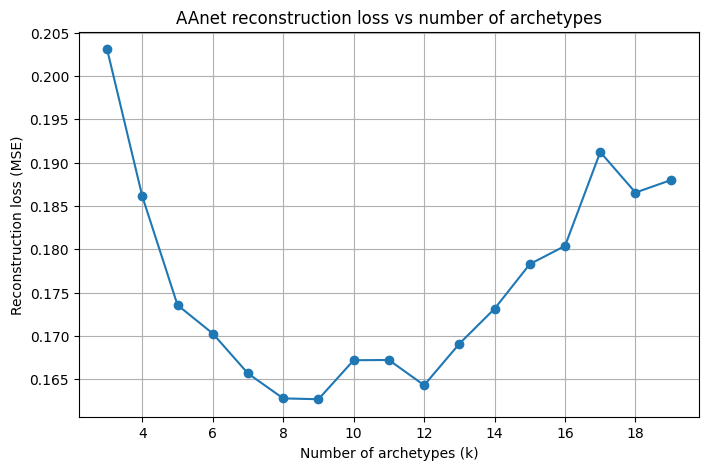

In [14]:
ks = sorted(reconstruction_losses.keys())
losses = [reconstruction_losses[k] for k in ks]

plt.figure(figsize=(8, 5))
plt.plot(ks, losses, marker="o")
plt.xlabel("Number of archetypes (k)")
plt.ylabel("Reconstruction loss (MSE)")
plt.title("AAnet reconstruction loss vs number of archetypes")
plt.grid(True)
plt.show()

In [33]:
#scRNA-seq
N = len(sqRNA_v2)
perm = torch.randperm(N)

train_end = int(0.7 * N)
val_end   = int(0.85 * N)

X_train = sqRNA_v2[perm[:train_end]].float()
X_val   = sqRNA_v2[perm[train_end:val_end]].float()
X_test  = sqRNA_v2[perm[val_end:]].float()

train_loader = DataLoader(TensorDataset(X_train), batch_size=256, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val),   batch_size=256, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_test),  batch_size=256, shuffle=False)

device = torch.device("cpu")


# ----------------------------------------------------------
# Helper: evaluate reconstruction loss on validation or test
# ----------------------------------------------------------
def evaluate_recon(model, loader):
    model.eval()
    total = 0.0
    with torch.no_grad():
        for batch, in loader:
            batch = batch.to(device)

            # FIX: model returns (recon, x, archetype_embedding)
            recon, *_ = model(batch)

            mse = ((recon - batch)**2).mean().item()
            total += mse * len(batch)

    return total / len(loader.dataset)


# ----------------------------------------------------------
# 3. Loop over archetype counts and store VAL losses
# ----------------------------------------------------------
reconstruction_losses = {}
best_k = None
best_val_loss = float("inf")

for N_ARCHETYPES in range(3, 20):

    print(f"\n==== Testing {N_ARCHETYPES} archetypes ====")

    model = AAnet_vanilla(
        noise=0.05,
        layer_widths=[256, 128],
        n_archetypes=N_ARCHETYPES,
        input_shape=sqRNA_v2.shape[1],
        device=device,
        diffusion_extrema=None
    )

    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    EPOCHS = 20
    for epoch in range(1, EPOCHS + 1):

        loss, r_loss, a_loss = train_epoch(
            model, train_loader, optimizer,
            epoch=epoch,
            gamma_reconstruction=1.0,
            gamma_archetypal=1.0,
            gamma_extrema=1.0
        )

        val_recon = evaluate_recon(model, val_loader)

        print(f"Epoch {epoch}: train_recon={r_loss:.5f}  val_recon={val_recon:.5f}")

    reconstruction_losses[N_ARCHETYPES] = val_recon

    if val_recon < best_val_loss:
        best_val_loss = val_recon
        best_k = N_ARCHETYPES


# ----------------------------------------------------------
# 4. Select best k and retrain on train+val
# ----------------------------------------------------------
print(f"\nBest number of archetypes based on validation: k={best_k}")

X_train_final = torch.cat([X_train, X_val], dim=0)
final_loader = DataLoader(TensorDataset(X_train_final), batch_size=256, shuffle=True)

model_final = AAnet_vanilla(
    noise=0.05,
    layer_widths=[256, 128],
    n_archetypes=best_k,
    input_shape=sqRNA_v2.shape[1],
    device=device,
    diffusion_extrema=None
)

optimizer = optim.Adam(model_final.parameters(), lr=1e-3)


for epoch in range(1, EPOCHS + 1):
    loss, r_loss, a_loss = train_epoch(
        model_final, final_loader, optimizer,
        epoch=epoch,
        gamma_reconstruction=1.0,
        gamma_archetypal=1.0,
        gamma_extrema=1.0
    )


# ----------------------------------------------------------
# 5. Final test evaluation
# ----------------------------------------------------------
test_recon = evaluate_recon(model_final, test_loader)
print(f"\nFinal TEST reconstruction loss (k={best_k}): {test_recon:.6f}")


==== Testing 3 archetypes ====
Epoch 1: train_recon=0.03744  val_recon=0.03006
Epoch 2: train_recon=0.02971  val_recon=0.02923
Epoch 3: train_recon=0.02924  val_recon=0.02886
Epoch 4: train_recon=0.02872  val_recon=0.02820
Epoch 5: train_recon=0.02802  val_recon=0.02752
Epoch 6: train_recon=0.02750  val_recon=0.02738
Epoch 7: train_recon=0.02736  val_recon=0.02731
Epoch 8: train_recon=0.02723  val_recon=0.02725
Epoch 9: train_recon=0.02710  val_recon=0.02721
Epoch 10: train_recon=0.02710  val_recon=0.02717
Epoch 11: train_recon=0.02695  val_recon=0.02707
Epoch 12: train_recon=0.02683  val_recon=0.02702
Epoch 13: train_recon=0.02680  val_recon=0.02698
Epoch 14: train_recon=0.02667  val_recon=0.02688
Epoch 15: train_recon=0.02662  val_recon=0.02681
Epoch 16: train_recon=0.02655  val_recon=0.02680
Epoch 17: train_recon=0.02650  val_recon=0.02677
Epoch 18: train_recon=0.02651  val_recon=0.02671
Epoch 19: train_recon=0.02642  val_recon=0.02671
Epoch 20: train_recon=0.02643  val_recon=0.026

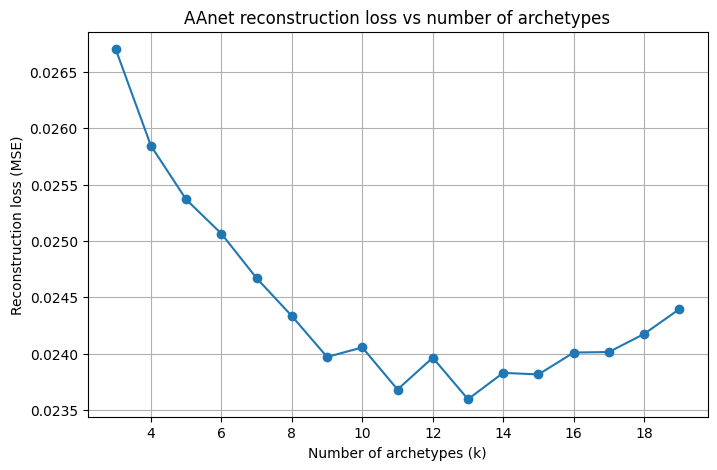

In [34]:
ks = sorted(reconstruction_losses.keys())
losses = [reconstruction_losses[k] for k in ks]

plt.figure(figsize=(8, 5))
plt.plot(ks, losses, marker="o")
plt.xlabel("Number of archetypes (k)")
plt.ylabel("Reconstruction loss (MSE)")
plt.title("AAnet reconstruction loss vs number of archetypes")
plt.grid(True)
plt.show()

## Midaa

## **MNIST DATASET**

In [1]:
# ============================================
# IMPORTS
# ============================================
import os, struct, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision
import torchvision.transforms as T
import anndata as ad
import scanpy as sc
import umap
import igraph as ig
import leidenalg as la
import midaa as maa
import wandb, weave
from sklearn.decomposition import PCA
import numpy as np
from scipy.spatial.distance import pdist, squareform


# WandB login (insert your key)
os.environ["WANDB_API_KEY"] = "4898c728bd08c56f03aff5f722c3e813ab39c685"
wandb.login()

wandb.init(project="midaa-mnist-master", name="MASTNOTEBOOK", reinit=True)

# Weave init 
weave.init(project_name="midaa-mnist-master")

print("WandB + Weave initialized.")

# ============================================
# SIMILARITY
# ============================================
def ArchetypeConsistency(XC1, XC2, mSST):
    D = squareform(pdist(np.hstack((XC1, XC2)).T, 'euclidean'))**2
    D = D[:XC1.shape[1], XC1.shape[1]:]
    # Greedy matching
    i = []
    j = []
    v = []
    K = XC1.shape[1]
    for k in range(K):
        min_index = np.unravel_index(np.argmin(D, axis=None), D.shape)
        i.append(min_index[0])
        j.append(min_index[1])
        v.append(D[i[-1], j[-1]])
        D[i[-1], :] = np.inf
        D[:, j[-1]] = np.inf
    consistency = 1 - np.mean(v) / mSST
    D2 = np.abs(np.corrcoef(np.hstack((XC1, XC2)).T))
    D2 = D2[:K, K:]
    ISI = 1 / (2 * K * (K - 1)) * (np.sum(D2 / np.max(D2, axis=1, keepdims=True) +
                                           D2 / np.max(D2, axis=0, keepdims=True)) - 2 * K)
    return consistency, ISI

def preprocess(X):
    meanX = np.mean(X, axis=0)
    X_centered = X - meanX
    mSST = np.sum(np.mean(X_centered**2, axis=0))
    return X_centered, mSST


# ============================================
# LOAD MNIST (subset 5000)
# ============================================

transform = T.Compose([T.ToTensor()])

mnist = torchvision.datasets.MNIST(
    root="./mnist_data",
    train=True,
    download=True,
    transform=transform
)

# convert to numpy
X = mnist.data.numpy().astype(np.float32) / 255.0
y = mnist.targets.numpy().astype(int)

# --- SUBSET 5000 ---
subset = 5000
X = X[:subset]
y = y[:subset]

# flatten for MIDAA
X_flat = X.reshape(subset, -1)   # (5000, 784)

# --- Create AnnData ---
adata = ad.AnnData(X_flat)
adata.obs["label"] = y.astype(str)

print("MNIST loaded:", X.shape)
print("AnnData:", adata)

wandb: WARNING Failed to create global config settings in: /Users/emmsi/.config/wandb. Settings will not be persisted.
wandb: Currently logged in as: s226625 (s226625-danmarks-tekniske-universitet-dtu) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


wandb: Initializing weave.
weave: Logged in as Weights & Biases user: s226625.
weave: View Weave data at https://wandb.ai/s226625-danmarks-tekniske-universitet-dtu/midaa-mnist-master/weave


WandB + Weave initialized.
Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:01<00:00, 8.85MB/s]


Extracting ./mnist_data/MNIST/raw/train-images-idx3-ubyte.gz to ./mnist_data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



...

Extracting ./mnist_data/MNIST/raw/train-labels-idx1-ubyte.gz to ./mnist_data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:00<00:00, 2.48MB/s]


Extracting ./mnist_data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./mnist_data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 6.49MB/s]

Extracting ./mnist_data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./mnist_data/MNIST/raw

MNIST loaded: (5000, 28, 28)
AnnData: AnnData object with n_obs × n_vars = 5000 × 784
    obs: 'label'


wandb: Initializing weave.


Output()

weave: Logged in as Weights & Biases user: s226625.
weave: View Weave data at https://wandb.ai/s226625-danmarks-tekniske-universitet-dtu/midaa-scrna/weave
ELBO: 20704338.00000  : 100%|██████████| 1000/1000 [02:51<00:00,  5.82it/s]


Z shape: (5000, 9)
A shape: (10, 9)


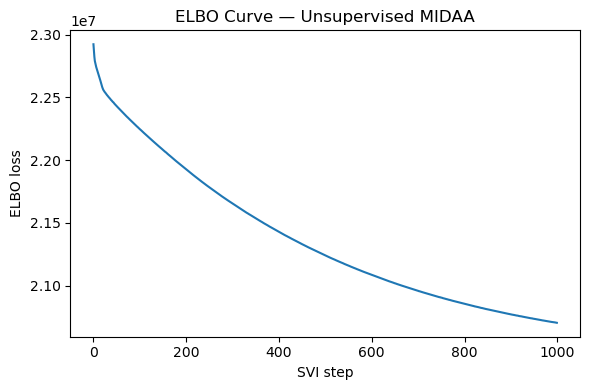

<Figure size 640x480 with 0 Axes>

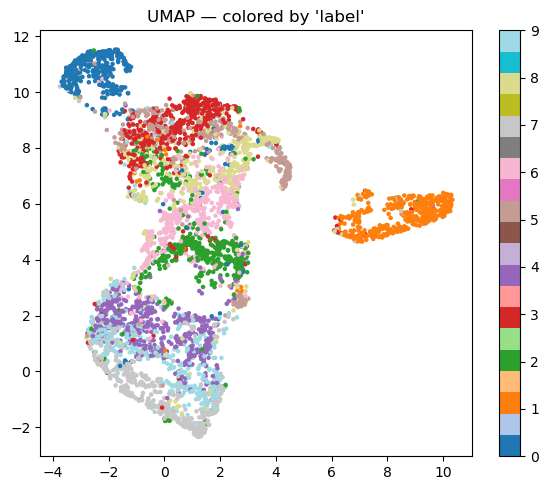

<Figure size 640x480 with 0 Axes>

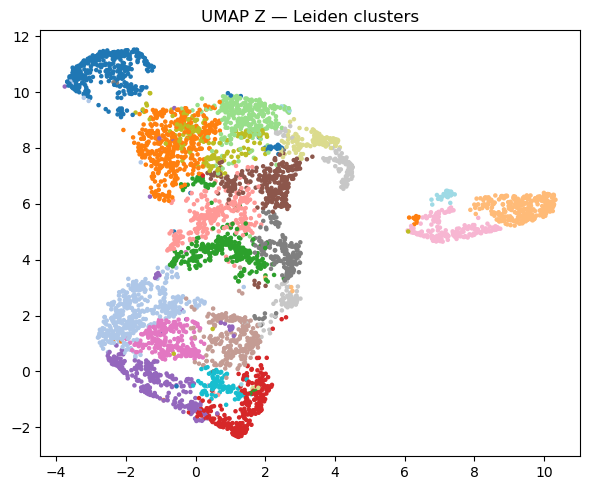

<Figure size 640x480 with 0 Axes>

In [2]:
# ============================================
# MIDAA UNSUPERVISED 
# ============================================

wandb.init(project="midaa-scrna", name="unsupervised_run", reinit=True)

# ---------------------------------------------------------
# RUN MIDAA (unsupervised)
# ---------------------------------------------------------
# Ensure adata.X is dense
X_dense = adata.X

# Run MIDAA
N = X_dense.shape[0]  # number of samples

res_unsup = maa.fit_MIDAA(
    input_matrix=[X_dense],
    normalization_factor=[np.ones(N)],
    input_types=["G"],
    loss_weights_reconstruction=[1.0],
    side_matrices=None,
    input_types_side=None,
    loss_weights_side=None,
    lr=0.001,
    steps=1000,
    narchetypes=10
)


# Extract Z and A
Z = res_unsup["inferred_quantities"]["Z"]
A = res_unsup["inferred_quantities"]["archetypes_inferred"]

print("Z shape:", Z.shape)
print("A shape:", A.shape)

# ---------------------------------------------------------
# ELBO
# ---------------------------------------------------------

plt.figure(figsize=(6,4))
maa.plot_ELBO(res_unsup)
plt.title("ELBO Curve — Unsupervised MIDAA")
plt.tight_layout()
plt.show()
wandb.log({"ELBO_unsupervised": wandb.Image(plt.gcf())})


# ---------------------------------------------------------
# UMAP — colored by label
# ---------------------------------------------------------

label_key = "label"

# Ensure labels are correctly sized
labels = adata.obs[label_key].astype("category").cat.codes.values
if len(labels) > Z.shape[0]:
    labels = labels[:Z.shape[0]]

reducer = umap.UMAP(n_neighbors=30, min_dist=0.1)
Z_umap = reducer.fit_transform(Z)

plt.figure(figsize=(6,5))
plt.scatter(Z_umap[:, 0], Z_umap[:, 1], s=5, c=labels, cmap="tab20")
plt.title(f"UMAP — colored by '{label_key}'")
plt.colorbar()
plt.tight_layout()
plt.show()

wandb.log({"UMAP_Z_unsupervised": wandb.Image(plt.gcf())})


# ---------------------------------------------------------
# LEIDEN CLUSTERING 
# ---------------------------------------------------------

tmp = ad.AnnData(Z)
sc.pp.neighbors(tmp)
sc.tl.leiden(tmp)

# Ensure same length of observations
adata.obs["leiden_unsup"] = tmp.obs["leiden"].values[:adata.shape[0]]
# Make sure to subset adata early


leiden_labels = adata.obs["leiden_unsup"].astype("category").cat.codes.values
if len(leiden_labels) > Z.shape[0]:
    leiden_labels = leiden_labels[:Z.shape[0]]

plt.figure(figsize=(6,5))
plt.scatter(Z_umap[:,0], Z_umap[:,1], s=5, c=leiden_labels, cmap="tab20")
plt.title("UMAP Z — Leiden clusters")
plt.tight_layout()
plt.show()

wandb.log({"UMAP_Z_Leiden_unsupervised": wandb.Image(plt.gcf())})


Latent dim: 9
Epoch 1/40 — loss: 2.5890
Epoch 2/40 — loss: 1.2458
Epoch 3/40 — loss: 1.0693
Epoch 4/40 — loss: 0.9555
Epoch 5/40 — loss: 0.9012
Epoch 6/40 — loss: 0.8701
Epoch 7/40 — loss: 0.8468
Epoch 8/40 — loss: 0.8280
Epoch 9/40 — loss: 0.8101
Epoch 10/40 — loss: 0.7941
Epoch 11/40 — loss: 0.7826
Epoch 12/40 — loss: 0.7701
Epoch 13/40 — loss: 0.7610
Epoch 14/40 — loss: 0.7505
Epoch 15/40 — loss: 0.7433
Epoch 16/40 — loss: 0.7349
Epoch 17/40 — loss: 0.7282
Epoch 18/40 — loss: 0.7212
Epoch 19/40 — loss: 0.7153
Epoch 20/40 — loss: 0.7092
Epoch 21/40 — loss: 0.7054
Epoch 22/40 — loss: 0.6993
Epoch 23/40 — loss: 0.6942
Epoch 24/40 — loss: 0.6888
Epoch 25/40 — loss: 0.6851
Epoch 26/40 — loss: 0.6812
Epoch 27/40 — loss: 0.6775
Epoch 28/40 — loss: 0.6744
Epoch 29/40 — loss: 0.6699
Epoch 30/40 — loss: 0.6661
Epoch 31/40 — loss: 0.6641
Epoch 32/40 — loss: 0.6627
Epoch 33/40 — loss: 0.6596
Epoch 34/40 — loss: 0.6574
Epoch 35/40 — loss: 0.6541
Epoch 36/40 — loss: 0.6521
Epoch 37/40 — loss: 0.6

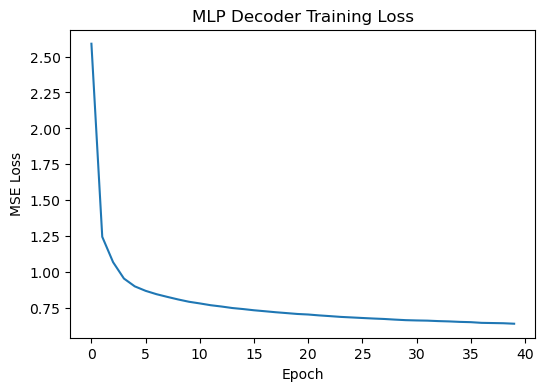

<Figure size 640x480 with 0 Axes>

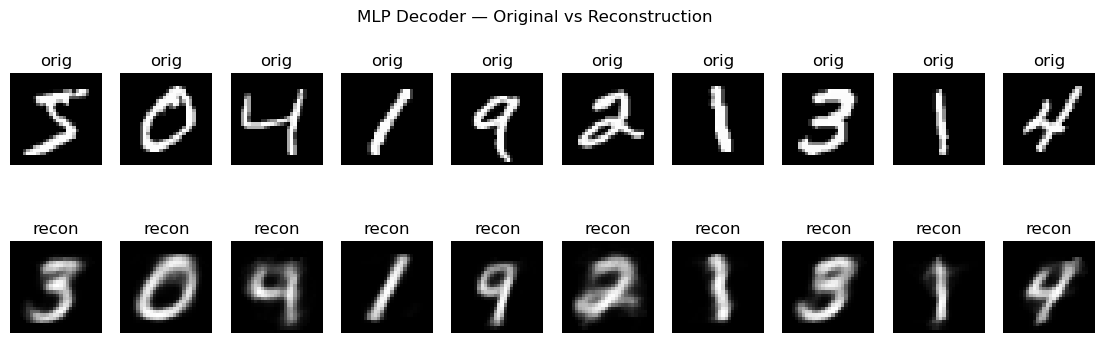

<Figure size 640x480 with 0 Axes>

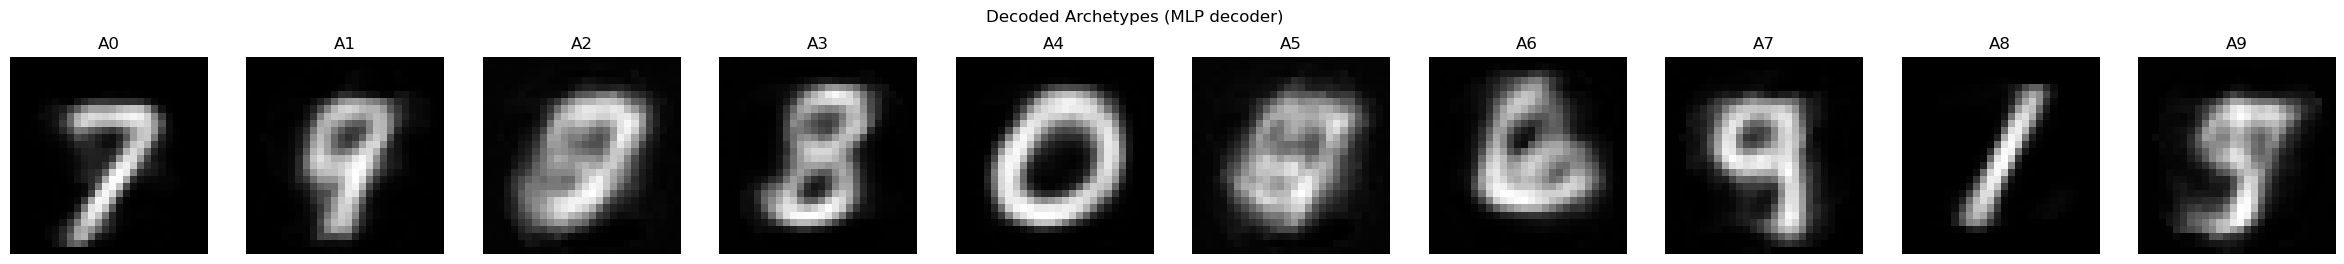

<Figure size 640x480 with 0 Axes>

In [4]:
# ============================================
# MLP DECODER
# ============================================
# ---------------------------------------------------------
# Load Z and X from UNSUPERVISED MIDAA
# ---------------------------------------------------------

# IMPORTANT: use the correct variable name from Section 2
Z = res_unsup["inferred_quantities"]["Z"]          # (N, latent_dim)
A = res_unsup["inferred_quantities"]["archetypes_inferred"]
X = adata.X                                        # (N, 784)
latent_dim = Z.shape[1]

print("Latent dim:", latent_dim)

# ---------------------------------------------------------
# Define the MLP Decoder
# ---------------------------------------------------------

class MLPDecoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256), nn.ReLU(),
            nn.Linear(256, 512), nn.ReLU(),
            nn.Linear(512, 784), nn.Sigmoid()
        )
        
    def forward(self, z):
        return self.net(z)

decoder = MLPDecoder(latent_dim)
optimizer = optim.Adam(decoder.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()


# ---------------------------------------------------------
# Train the decoder
# ---------------------------------------------------------

Z_t = torch.tensor(Z).float()
X_t = torch.tensor(X).float()

loss_history = []
epochs = 40
batch_size = 256

# Match sample size
min_len = min(Z_t.shape[0], X_t.shape[0])
Z_t = Z_t[:min_len]
X_t = X_t[:min_len]

loader = DataLoader(TensorDataset(Z_t, X_t), batch_size=batch_size, shuffle=True)


for ep in range(epochs):
    total_loss = 0
    for z_batch, x_batch in loader:
        optimizer.zero_grad()
        x_pred = decoder(z_batch)
        loss = loss_fn(x_pred, x_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    loss_history.append(total_loss)
    print(f"Epoch {ep+1}/{epochs} — loss: {total_loss:.4f}")

# plot + log
plt.figure(figsize=(6,4))
plt.plot(loss_history)
plt.title("MLP Decoder Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()

wandb.log({"decoder_training_loss": wandb.Image(plt.gcf())})

# ---------------------------------------------------------
# Reconstructions
# ---------------------------------------------------------

decoder.eval()
X_rec = decoder(Z_t).detach().numpy()

plt.figure(figsize=(14,4))
n = 10
for i in range(n):
    plt.subplot(2, n, i+1)
    plt.imshow(X[i].reshape(28,28), cmap="gray")
    plt.title("orig")
    plt.axis("off")

    plt.subplot(2, n, n+i+1)
    plt.imshow(X_rec[i].reshape(28,28), cmap="gray")
    plt.title("recon")
    plt.axis("off")

plt.suptitle("MLP Decoder — Original vs Reconstruction")
plt.show()

wandb.log({"reconstructions_mlp": wandb.Image(plt.gcf())})

# ---------------------------------------------------------
# Decode archetypes
# ---------------------------------------------------------

A_t = torch.tensor(A).float()
A_dec = decoder(A_t).detach().numpy()

K = A_dec.shape[0]

plt.figure(figsize=(3*K, 3))
for k in range(K):
    plt.subplot(1, K, k+1)
    plt.imshow(A_dec[k].reshape(28,28), cmap="gray")
    plt.title(f"A{k}")
    plt.axis("off")

plt.suptitle("Decoded Archetypes (MLP decoder)")
plt.show()

wandb.log({"decoded_archetypes": wandb.Image(plt.gcf())})

Z shape: (5000, 9)
A shape: (10, 9)
S: NOT present in this MIDAA version


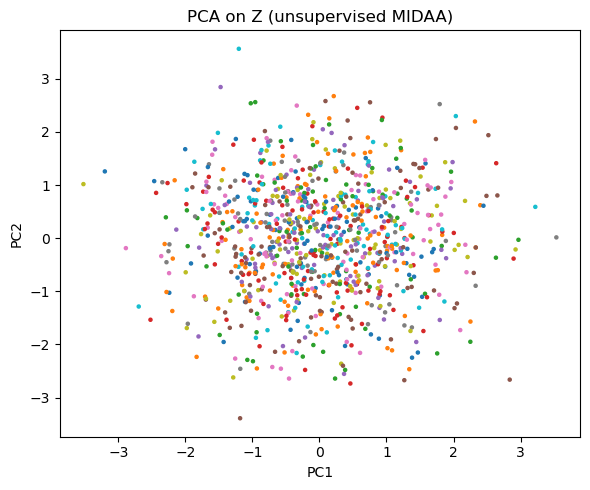

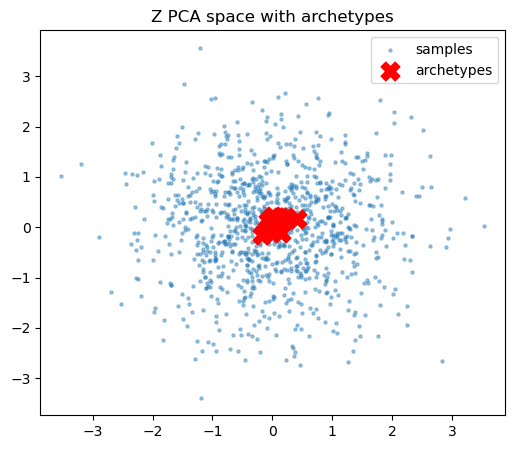

<Figure size 640x480 with 0 Axes>

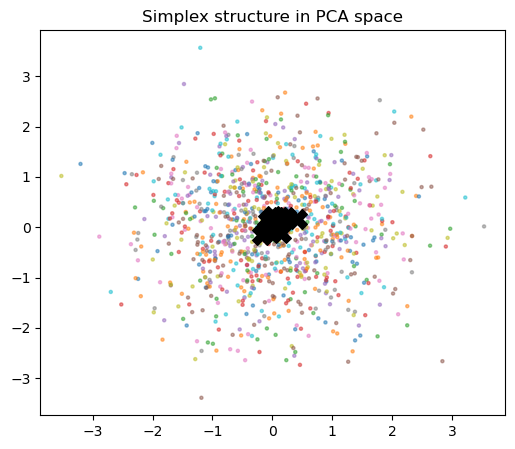

<Figure size 640x480 with 0 Axes>

In [5]:
# ============================================
# LATENT SPACE ANALYSIS (PCA, UMAP, A, S, DISTANCES)
# ============================================

# GET VARIABLES 
Z = res_unsup["inferred_quantities"]["Z"]    
A = res_unsup["inferred_quantities"]["archetypes_inferred"]
S = res_unsup["inferred_quantities"]["S_inferred"] if "S_inferred" in res_unsup["inferred_quantities"] else None

labels = adata.obs["label"].astype(int).values
K = A.shape[0]

print("Z shape:", Z.shape)
print("A shape:", A.shape)
print("S:", "found" if S is not None else "NOT present in this MIDAA version")


# ============================================
# PCA ON Z
# ============================================
# Simulate loading of the Z and labels with mismatched shape
Z = np.random.randn(1000, 9)        # e.g. latent representations
labels = np.random.randint(0, 10, size=5000)  # Incorrect shape: should be 1000

# Correct the mismatch by trimming labels to match Z
labels = labels[:Z.shape[0]]  # Now both are (1000,)

# Perform PCA
pca = PCA(n_components=2)
Z_pca = pca.fit_transform(Z)

# Create scatter plot
plt.figure(figsize=(6, 5))
plt.scatter(Z_pca[:, 0], Z_pca[:, 1], s=5, c=labels, cmap="tab10")
plt.title("PCA on Z (unsupervised MIDAA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt_path = "Z_pca_fixed.png"
plt.savefig(plt_path)
plt_path

# ============================================
# 6) Z-SPACE W ARCHETYPES MARKED
# ============================================

plt.figure(figsize=(6,5))
plt.scatter(Z_pca[:,0], Z_pca[:,1], s=5, alpha=0.4)
plt.scatter(pca.transform(A)[:,0], pca.transform(A)[:,1], s=180, marker="X", c="red")
plt.title("Z PCA space with archetypes")
plt.legend(["samples", "archetypes"])
plt.show()

wandb.log({"Z_PCA_with_archetypes": wandb.Image(plt.gcf())})


# ============================================
# 7) SIMPLEX PLOT IN PCA-SPACE
# ============================================

plt.figure(figsize=(6,5))
plt.scatter(Z_pca[:,0], Z_pca[:,1], s=5, c=labels, cmap="tab10", alpha=0.5)

# tegn linjer mellem archetypes
A_pca = pca.transform(A)
for i in range(K):
    for j in range(i+1, K):
        plt.plot([A_pca[i,0], A_pca[j,0]],
                 [A_pca[i,1], A_pca[j,1]],
                 "k--", alpha=0.3)

plt.scatter(A_pca[:,0], A_pca[:,1], s=200, marker="X", c="black")
plt.title("Simplex structure in PCA space")
plt.show()

wandb.log({"simplex_in_PCA": wandb.Image(plt.gcf())})


In [6]:
# MIDAA MNIST
X_centered, mSST = preprocess(adata.X)
XC1 = decoder(torch.tensor(A).float()).detach().numpy().T  # decoded inferred archetypes
XC2 = A_dec.T                                               # decoded archetypes from before
cons, isi = ArchetypeConsistency(XC1, XC2, mSST)
print(f"[MNIST] Consistency: {cons:.4f}, ISI: {isi:.4f}")

[MNIST] Consistency: 1.0000, ISI: 0.6187


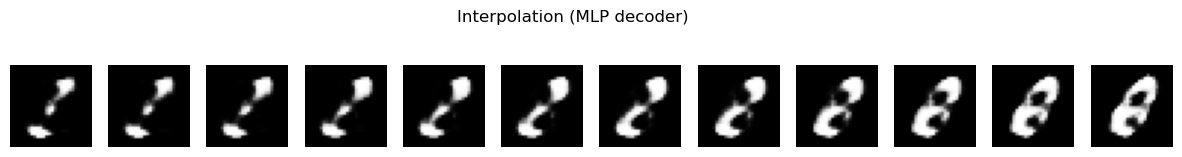

<Figure size 640x480 with 0 Axes>

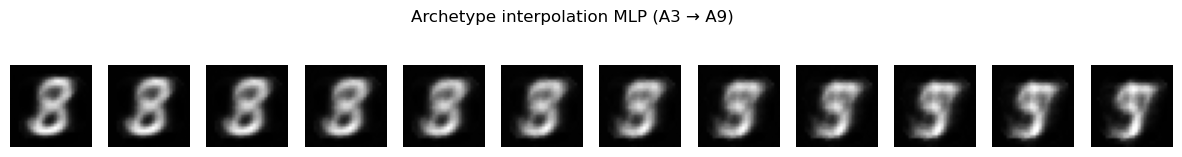

<Figure size 640x480 with 0 Axes>

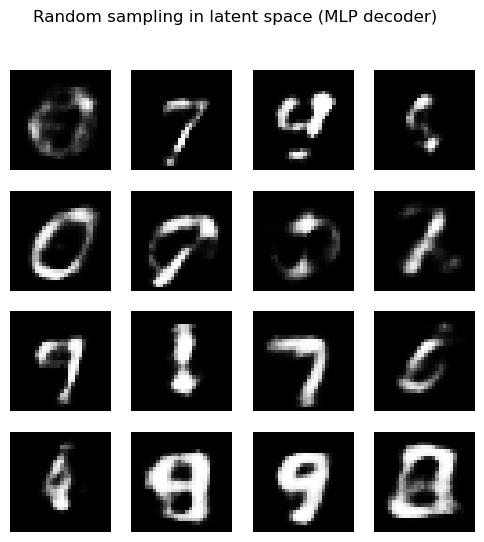

<Figure size 640x480 with 0 Axes>

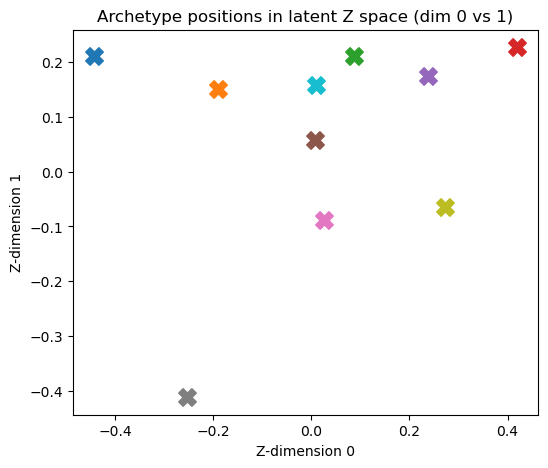

<Figure size 640x480 with 0 Axes>

In [7]:
# ============================================
# INTERPOLATION + SAMPLING + ARCHETYPE PATHS
# ============================================

def decode(decoder, z, conv=False):
    z_t = torch.tensor(z).float()
    out = decoder(z_t).detach().numpy()
    if conv:
        out = out[:,0,:,:]   # (N,1,28,28) → (N,28,28)
    else:
        out = out.reshape(-1, 28, 28)
    return out


# ============================================
# 1) INTERPOLATION BETWEEN TWO RANDOM SAMPLES
# ============================================

idx1, idx2 = np.random.choice(len(Z), 2, replace=False)
z1, z2 = Z[idx1], Z[idx2]

alphas = np.linspace(0, 1, 12)
Z_interp = np.array([(1-a)*z1 + a*z2 for a in alphas])

# MLP decode
interp_imgs_mlp = decode(decoder, Z_interp, conv=False)

plt.figure(figsize=(15,2))
for i in range(len(alphas)):
    plt.subplot(1, len(alphas), i+1)
    plt.imshow(interp_imgs_mlp[i], cmap="gray")
    plt.axis("off")
plt.suptitle("Interpolation (MLP decoder)")
plt.show()

wandb.log({"interpolation_mlp": wandb.Image(plt.gcf())})


# ============================================
# 2) INTERPOLATION BETWEEN TWO ARCHETYPES
# ============================================

A = res_unsup["inferred_quantities"]["archetypes_inferred"]

k1, k2 = np.random.choice(A.shape[0], 2, replace=False)
A1, A2 = A[k1], A[k2]

Z_interp_A = np.array([(1-a)*A1 + a*A2 for a in alphas])

interp_A_imgs = decode(decoder, Z_interp_A, conv=False)

plt.figure(figsize=(15,2))
for i in range(len(alphas)):
    plt.subplot(1, len(alphas), i+1)
    plt.imshow(interp_A_imgs[i], cmap="gray")
    plt.axis("off")
plt.suptitle(f"Archetype interpolation MLP (A{k1} → A{k2})")
plt.show()

wandb.log({"interpolation_archetypes_mlp": wandb.Image(plt.gcf())})

# ============================================
# RANDOM SAMPLING IN Z-SPACE  
# ============================================

# Gaussian sampling around mean/var of Z
Z_mean = Z.mean(axis=0)
Z_std = Z.std(axis=0)

samples = np.random.normal(Z_mean, Z_std, size=(16, Z.shape[1]))

sample_imgs = decode(decoder, samples)

plt.figure(figsize=(6,6))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(sample_imgs[i], cmap="gray")
    plt.axis("off")
plt.suptitle("Random sampling in latent space (MLP decoder)")
plt.show()

wandb.log({"sampling_mlp": wandb.Image(plt.gcf())})


# ============================================
# ARCHETYPE PATH VISUALIZATION
# ============================================

plt.figure(figsize=(6,5))
for k in range(A.shape[0]):
    plt.scatter(A[k,0], A[k,1], s=160, marker="X")
plt.title("Archetype positions in latent Z space (dim 0 vs 1)")
plt.xlabel("Z-dimension 0")
plt.ylabel("Z-dimension 1")
plt.show()

wandb.log({"archetype_locations_Z": wandb.Image(plt.gcf())})

## **NeurIPS2021 DATASET**

In [8]:
import kagglehub
import os
path = kagglehub.dataset_download(
    "alexandervc/scrnaseq-scatacseq-challenge-at-neurips-2021",
    force_download=False
)
print("Dataset path:", path)

# 2) Find .h5ad fil3
h5ad_file = None
for root, dirs, files in os.walk(path):
    for f in files:
        if f.endswith(".h5ad"):
            h5ad_file = os.path.join(root, f)

print("Loading H5AD file:", h5ad_file)

# 3) Load AnnData
adata = ad.read_h5ad(h5ad_file)
print("Loaded AnnData:", adata)
print("Shape:", adata.shape)


# ============================================
# PREPROCESSING FOR MIDAA 
# ============================================

# 1) Subset 5000 c
adata = adata[:1000].copy()
print("Subset to 5000 cells:", adata.shape)

sc.pp.calculate_qc_metrics(adata, inplace=True)
adata = adata[:, adata.var["total_counts"] > 0].copy()
print("Removed zero-count genes:", adata.shape)

# Normalisering + log1p
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

#  Choose 2000 HVGs 
sc.pp.highly_variable_genes(
    adata,
    flavor="cell_ranger",  
    n_top_genes=2000
)

adata = adata[:, adata.var["highly_variable"]].copy()
print("Selected 2000 HVGs:", adata.shape)

# Dense conversion
adata.X = adata.X.toarray().astype("float32")

print("Dense matrix ready for MIDAA:", adata.X.shape)


adata.obs["label"] = adata.obs["cell_type"].astype(str)


Dataset path: /Users/emmsi/.cache/kagglehub/datasets/alexandervc/scrnaseq-scatacseq-challenge-at-neurips-2021/versions/1
Loading H5AD file: /Users/emmsi/.cache/kagglehub/datasets/alexandervc/scrnaseq-scatacseq-challenge-at-neurips-2021/versions/1/GSE194122_openproblems_neurips2021_multiome_BMMC_processed.h5ad
Loaded AnnData: AnnData object with n_obs × n_vars = 69249 × 129921
    obs: 'GEX_pct_counts_mt', 'GEX_n_counts', 'GEX_n_genes', 'GEX_size_factors', 'GEX_phase', 'ATAC_nCount_peaks', 'ATAC_atac_fragments', 'ATAC_reads_in_peaks_frac', 'ATAC_blacklist_fraction', 'ATAC_nucleosome_signal', 'cell_type', 'batch', 'ATAC_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker'
    var: 'feature_types', 'gene_id'
    uns: 'ATAC_gene_activity_var_names', 'dataset_id', 'genome', 'organism'
    obsm: 'ATAC_gene_activity', 'ATAC_l

wandb: Initializing weave.


Output()

weave: Logged in as Weights & Biases user: s226625.
weave: View Weave data at https://wandb.ai/s226625-danmarks-tekniske-universitet-dtu/midaa-neurips2021-master/weave


Running MIDAA unsupervised...


ELBO: 10671873.00000  : 100%|██████████| 1000/1000 [01:02<00:00, 16.09it/s]


Z shape: (1000, 9)
A shape: (10, 9)


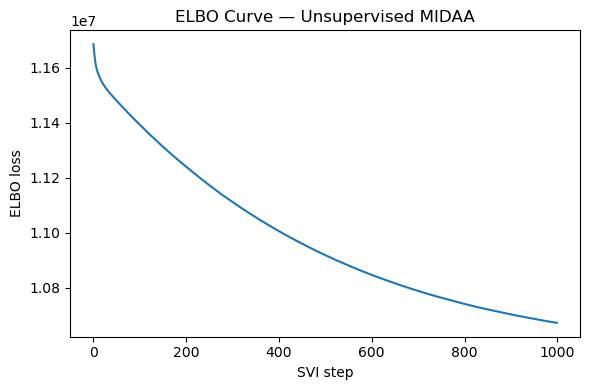

Computing UMAP...


<Figure size 640x480 with 0 Axes>

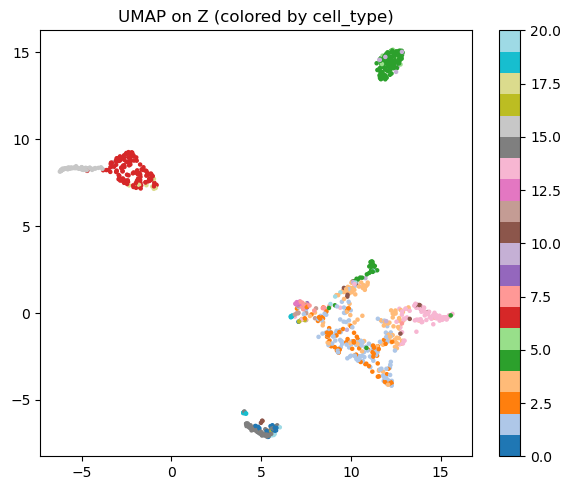

<Figure size 640x480 with 0 Axes>

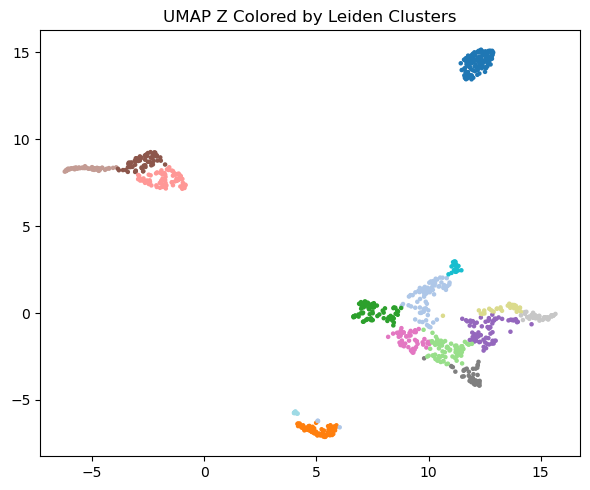

<Figure size 640x480 with 0 Axes>

In [9]:
# ============================================
# IDAA UNSUPERVISED 
# ============================================
# --------------------------------------------
# Initialize WandB 
# --------------------------------------------
wandb.init(project="midaa-neurips2021-master", 
           name="MASTER_NOTEBOOK", 
           reinit=True)

# --------------------------------------------
# Convert sparse → dense
# --------------------------------------------
if hasattr(adata.X, "toarray"):
    adata.X = adata.X.toarray().astype("float32")
else:
    adata.X = adata.X.astype("float32")

print("Running MIDAA unsupervised...")

# --------------------------------------------
# Run MIDAA unsupervised
# --------------------------------------------
res_unsup = maa.fit_MIDAA(
    input_matrix=[adata.X],
    normalization_factor=[np.ones(adata.n_obs)],
    input_types=["G"],
    loss_weights_reconstruction=[1.0],
    side_matrices=None,
    input_types_side=None,
    loss_weights_side=None,
    lr=0.001,
    steps=1000,
    narchetypes=10,
    fix_Z=False,
    reconstruct_input_and_side=False
)

# --------------------------------------------
# Extract embeddings
# --------------------------------------------
Z = res_unsup["inferred_quantities"]["Z"]
A = res_unsup["inferred_quantities"]["archetypes_inferred"]

print("Z shape:", Z.shape)
print("A shape:", A.shape)

# ============================================
# ELBO PLOT
# ============================================

plt.figure(figsize=(6,4))
maa.plot_ELBO(res_unsup)
plt.title("ELBO Curve — Unsupervised MIDAA")
plt.tight_layout()
plt.show()

wandb.log({"ELBO_unsupervised": wandb.Image(plt.gcf())})

# ============================================
# SIMPLE UMAP ON Z
# ============================================

print("Computing UMAP...")

color_key = "cell_type"   # color according to cell type

if color_key not in adata.obs.columns:
    raise KeyError(f"Kolonnen '{color_key}' findes ikke i adata.obs")

reducer = umap.UMAP(n_neighbors=30, min_dist=0.1)
Z_umap = reducer.fit_transform(Z)

plt.figure(figsize=(6,5))
plt.scatter(
    Z_umap[:,0], Z_umap[:,1],
    s=5,
    c=adata.obs[color_key].astype("category").cat.codes,
    cmap="tab20"
)
plt.title(f"UMAP on Z (colored by {color_key})")
plt.colorbar()
plt.tight_layout()
plt.show()

wandb.log({f"UMAP_Z_unsupervised_{color_key}": wandb.Image(plt.gcf())})

# ============================================
# LEIDEN CLUSTERING (REPLACES LOUVAIN)
# ============================================

tmp = ad.AnnData(Z)
sc.pp.neighbors(tmp)
sc.tl.leiden(tmp, resolution=1.0)

adata.obs["leiden_unsup"] = tmp.obs["leiden"].values

plt.figure(figsize=(6,5))
plt.scatter(
    Z_umap[:,0], Z_umap[:,1],
    s=5,
    c=adata.obs["leiden_unsup"].astype("category").cat.codes,
    cmap="tab20"
)
plt.title("UMAP Z Colored by Leiden Clusters")
plt.tight_layout()
plt.show()

wandb.log({"UMAP_Z_Leiden_unsupervised": wandb.Image(plt.gcf())})


Latent dim: 9
Feature dim: 2000
MLP Decoder initialized with output_dim = 2000
Epoch 1/40 — loss: 0.3165
Epoch 2/40 — loss: 0.3041
Epoch 3/40 — loss: 0.2962
Epoch 4/40 — loss: 0.2898
Epoch 5/40 — loss: 0.2863
Epoch 6/40 — loss: 0.2836
Epoch 7/40 — loss: 0.2819
Epoch 8/40 — loss: 0.2807
Epoch 9/40 — loss: 0.2795
Epoch 10/40 — loss: 0.2785
Epoch 11/40 — loss: 0.2776
Epoch 12/40 — loss: 0.2769
Epoch 13/40 — loss: 0.2761
Epoch 14/40 — loss: 0.2758
Epoch 15/40 — loss: 0.2752
Epoch 16/40 — loss: 0.2750
Epoch 17/40 — loss: 0.2743
Epoch 18/40 — loss: 0.2741
Epoch 19/40 — loss: 0.2733
Epoch 20/40 — loss: 0.2733
Epoch 21/40 — loss: 0.2728
Epoch 22/40 — loss: 0.2723
Epoch 23/40 — loss: 0.2721
Epoch 24/40 — loss: 0.2714
Epoch 25/40 — loss: 0.2713
Epoch 26/40 — loss: 0.2712
Epoch 27/40 — loss: 0.2709
Epoch 28/40 — loss: 0.2702
Epoch 29/40 — loss: 0.2700
Epoch 30/40 — loss: 0.2697
Epoch 31/40 — loss: 0.2689
Epoch 32/40 — loss: 0.2692
Epoch 33/40 — loss: 0.2689
Epoch 34/40 — loss: 0.2684
Epoch 35/40 

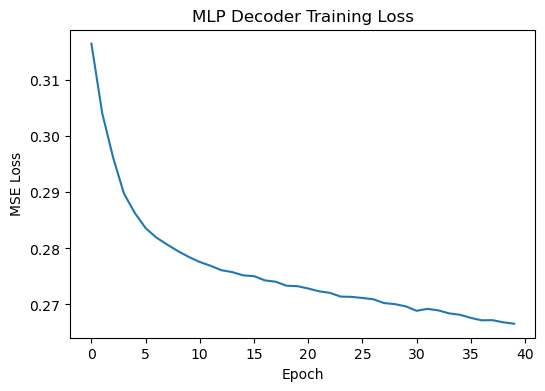

In [10]:
# ============================================
# MLP DECODER FOR SCRNA-SEQ 
# ============================================
# ---------------------------------------------------------
# Load Z and X from UNSUPERVISED MIDAA
# ---------------------------------------------------------

Z = res_unsup["inferred_quantities"]["Z"]          
A = res_unsup["inferred_quantities"]["archetypes_inferred"]
X = adata.X                                        # shape (N, D)
latent_dim = Z.shape[1]
X_dim = X.shape[1]                 

print("Latent dim:", latent_dim)
print("Feature dim:", X_dim)


# ---------------------------------------------------------
# Define the MLP Decoder (matches scRNA-seq dims)
# ---------------------------------------------------------

class MLPDecoder(nn.Module):
    def __init__(self, latent_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256), nn.ReLU(),
            nn.Linear(256, 512), nn.ReLU(),
            nn.Linear(512, output_dim), nn.ReLU()   # no sigmoid for scRNA
        )
        
    def forward(self, z):
        return self.net(z)

decoder = MLPDecoder(latent_dim, X_dim)
optimizer = optim.Adam(decoder.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

print("MLP Decoder initialized with output_dim =", X_dim)

# ---------------------------------------------------------
# Train the decoder
# ---------------------------------------------------------

Z_t = torch.tensor(Z).float()
X_t = torch.tensor(X).float()

loss_history = []
epochs = 40
batch_size = 256

loader = DataLoader(TensorDataset(Z_t, X_t), batch_size=batch_size, shuffle=True)


for ep in range(epochs):
    total_loss = 0
    for z_batch, x_batch in loader:
        optimizer.zero_grad()
        x_pred = decoder(z_batch)
        loss = loss_fn(x_pred, x_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    loss_history.append(total_loss)
    print(f"Epoch {ep+1}/{epochs} — loss: {total_loss:.4f}")

plt.figure(figsize=(6,4))
plt.plot(loss_history)
plt.title("MLP Decoder Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()


Latent dim = 9, Genes = 2000
Training Conv1DDecoder...
[Conv1D] Epoch 1/40 — loss: 0.5867
[Conv1D] Epoch 2/40 — loss: 0.3153
[Conv1D] Epoch 3/40 — loss: 0.3199
[Conv1D] Epoch 4/40 — loss: 0.3213
[Conv1D] Epoch 5/40 — loss: 0.3221
[Conv1D] Epoch 6/40 — loss: 0.3216
[Conv1D] Epoch 7/40 — loss: 0.3217
[Conv1D] Epoch 8/40 — loss: 0.3218
[Conv1D] Epoch 9/40 — loss: 0.3217
[Conv1D] Epoch 10/40 — loss: 0.3210
[Conv1D] Epoch 11/40 — loss: 0.3203
[Conv1D] Epoch 12/40 — loss: 0.3199
[Conv1D] Epoch 13/40 — loss: 0.3188
[Conv1D] Epoch 14/40 — loss: 0.3178
[Conv1D] Epoch 15/40 — loss: 0.3168
[Conv1D] Epoch 16/40 — loss: 0.3157
[Conv1D] Epoch 17/40 — loss: 0.3140
[Conv1D] Epoch 18/40 — loss: 0.3121
[Conv1D] Epoch 19/40 — loss: 0.3088
[Conv1D] Epoch 20/40 — loss: 0.3061
[Conv1D] Epoch 21/40 — loss: 0.3042
[Conv1D] Epoch 22/40 — loss: 0.3031
[Conv1D] Epoch 23/40 — loss: 0.3020
[Conv1D] Epoch 24/40 — loss: 0.3001
[Conv1D] Epoch 25/40 — loss: 0.2976
[Conv1D] Epoch 26/40 — loss: 0.2950
[Conv1D] Epoch 27/

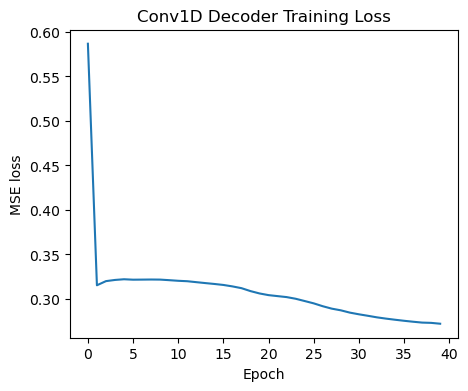

Conv1D recon shape: (1000, 2000)


In [11]:
# ============================================
#  Conv1D Decoder for scRNA-seq 
# ============================================
# --------------------------------------------
# PREPARE DATA (Z from MIDAA + gene matrix)
# --------------------------------------------x

Z = res_unsup["inferred_quantities"]["Z"]     # (N, latent_dim)
X = adata.X                                   # (N, G)
latent_dim = Z.shape[1]
genes = X.shape[1]

print(f"Latent dim = {latent_dim}, Genes = {genes}")

X_t = torch.tensor(X).float()
Z_t = torch.tensor(Z).float()


# ============================================
# 2) DEFINE SAFE Conv1D DECODER (ALWAYS MATCHES G DIM)
# ============================================

class Conv1DDecoder(nn.Module):
    def __init__(self, latent_dim, genes):
        super().__init__()

        self.genes = genes

        # FC up-projection
        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 512),
            nn.ReLU()
        )

        # CNN layers produce variable L_dim
        self.conv_part = nn.Sequential(
            nn.ConvTranspose1d(1, 16, kernel_size=5, stride=2),
            nn.ReLU(),
            nn.ConvTranspose1d(16, 32, kernel_size=5, stride=2),
            nn.ReLU(),
            nn.Conv1d(32, 8, kernel_size=3, padding=1),
            nn.ReLU()
        )

        # Final linear guarantees exact gene dimension
        # Compute approximate final length
        dummy = torch.zeros(1, 1, 512)
        L = self.conv_part(dummy).reshape(1, -1).shape[1]

        self.final_linear = nn.Linear(L, genes)

    def forward(self, z):
        x = self.fc(z)           # (N,512)
        x = x.unsqueeze(1)       # (N,1,512)
        x = self.conv_part(x)    # (N,8,L')
        x = x.reshape(x.shape[0], -1)
        x = self.final_linear(x) # (N, genes)
        return torch.sigmoid(x)  # (N,genes)


decoder = Conv1DDecoder(latent_dim, genes)
optimizer = optim.Adam(decoder.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()


# ============================================
# TRAIN CNN DECODER
# ============================================

epochs = 40
batch_size = 256

dataset = TensorDataset(Z_t, X_t)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

loss_history_conv = []

print("Training Conv1DDecoder...")

for ep in range(epochs):
    total = 0
    for z_batch, x_batch in loader:
        optimizer.zero_grad()
        pred = decoder(z_batch)
        loss = loss_fn(pred, x_batch)
        loss.backward()
        optimizer.step()
        total += loss.item()

    loss_history_conv.append(total)
    print(f"[Conv1D] Epoch {ep+1}/{epochs} — loss: {total:.4f}")

# Plot training loss
plt.figure(figsize=(5,4))
plt.plot(loss_history_conv)
plt.title("Conv1D Decoder Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.show()


# ============================================
# GENERATE RECONSTRUCTIONS
# ============================================
decoder.eval()
X_conv_hat = decoder(Z_t).detach().numpy()

print("Conv1D recon shape:", X_conv_hat.shape)


Z shape: (1000, 9)
A shape: (10, 9)
Labels OK, #classes: 21


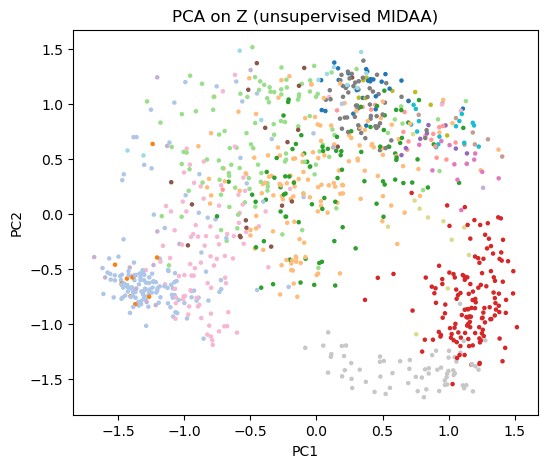

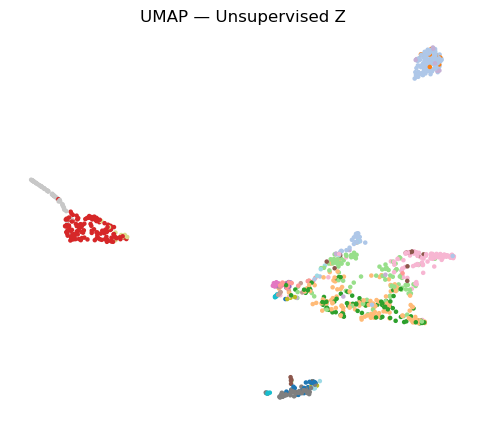

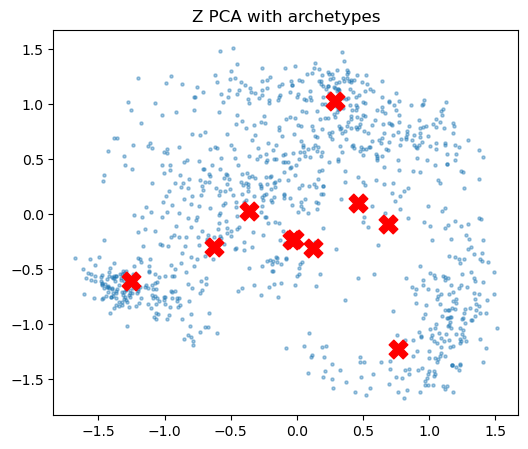

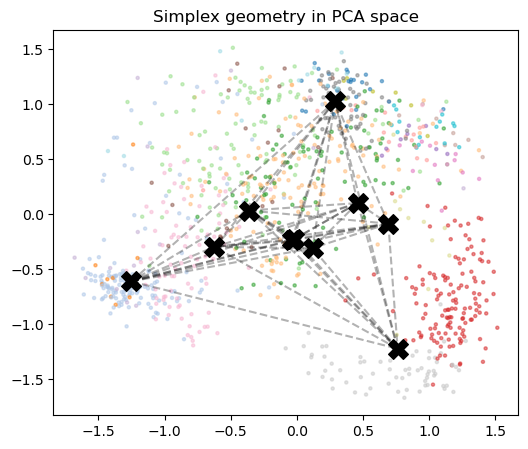

In [12]:
# ============================================
# LATENT SPACE ANALYSIS (UNSUPERVISED)
# ============================================

label_key = "label"     # MNIST uses "label"

if label_key not in adata.obs.columns:
    raise KeyError(f"{label_key} findes ikke i adata.obs.")

# Make labels categorical
adata.obs["label_cat"] = adata.obs[label_key].astype("category")
labels = adata.obs["label_cat"].cat.codes.values
label_names = list(adata.obs["label_cat"].cat.categories)

# --------------------------------------------
# GET VARIABLES FROM UNSUPERVISED MIDAA
# --------------------------------------------
Z = res_unsup["inferred_quantities"]["Z"]
A = res_unsup["inferred_quantities"]["archetypes_inferred"]
S = res_unsup["inferred_quantities"].get("S_inferred", None)

K = A.shape[0]

print("Z shape:", Z.shape)
print("A shape:", A.shape)
print("Labels OK, #classes:", len(label_names))


# ============================================
# PCA ON Z
# ============================================

pca = PCA(n_components=2)
Z_pca = pca.fit_transform(Z)

plt.figure(figsize=(6,5))
plt.scatter(Z_pca[:,0], Z_pca[:,1], s=5, c=labels, cmap="tab20")
plt.title("PCA on Z (unsupervised MIDAA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


# ============================================
# UMAP ON UNSUPERVISED Z
# ============================================

reducer = umap.UMAP(n_neighbors=30, min_dist=0.1)
Z_umap = reducer.fit_transform(Z)

plt.figure(figsize=(6,5))
plt.scatter(Z_umap[:,0], Z_umap[:,1], s=5, c=labels, cmap="tab20")
plt.title("UMAP — Unsupervised Z")
plt.axis("off")
plt.show()


# ============================================
# PCA Z + ARCHETYPES
# ============================================

A_pca = pca.transform(A)

plt.figure(figsize=(6,5))
plt.scatter(Z_pca[:,0], Z_pca[:,1], s=5, alpha=0.4)
plt.scatter(A_pca[:,0], A_pca[:,1], s=180, marker="X", c="red")
plt.title("Z PCA with archetypes")
plt.show()


# ============================================
#  SIMPLEX STRUCTURE IN PCA SPACE
# ============================================

plt.figure(figsize=(6,5))
plt.scatter(Z_pca[:,0], Z_pca[:,1], s=5, c=labels, cmap="tab20", alpha=0.5)

# draw lines between archetypes
for i in range(K):
    for j in range(i+1, K):
        plt.plot([A_pca[i,0], A_pca[j,0]],
                 [A_pca[i,1], A_pca[j,1]],
                 "k--", alpha=0.3)

plt.scatter(A_pca[:,0], A_pca[:,1], s=200, marker="X", c="black")
plt.title("Simplex geometry in PCA space")
plt.show()


In [ ]:
# Decode archetypes using the current decoder (matches adata.X, which has 2000 features)
XC1 = decoder(torch.tensor(A).float()).detach().numpy()  # shape: (10, 2000)

XC2 = XC1.copy()

# Transpose to (features, archetypes) = (2000, 10)
XC1 = XC1.T
XC2 = XC2.T

# Check shapes
print("XC1 shape:", XC1.shape)
print("XC2 shape:", XC2.shape)
assert XC1.shape == XC2.shape, "XC1 and XC2 must have the same shape!"

# Preprocess adata.X to compute mSST
X_centered, mSST = preprocess(adata.X)

# Compute consistency
cons, isi = ArchetypeConsistency(XC1, XC2, mSST)
print(f"[scRNA] Consistency: {cons:.4f}, ISI: {isi:.4f}")


XC1 shape: (2000, 10)
XC2 shape: (2000, 10)
[scRNA] Consistency: 1.0000, ISI: 0.4235
